In [ ]:
import tensorflow as tf
import pandas as pd
import kagglehub
import pathlib
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

Descargamos el dataset que necesitaremos para nuestro proyecto

In [ ]:
path_with_masks = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")

path_with_masks = pathlib.Path(path_with_masks).with_suffix('')
print(path_with_masks)

100%|██████████| 2.59G/2.59G [02:08<00:00, 21.7MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2


Guardamos en una variable las rutas de las imagenes y de las mascaras

In [ ]:
images_path = pathlib.Path(path_with_masks).joinpath('images').with_suffix('')
masks_path = pathlib.Path(path_with_masks).joinpath('masks').with_suffix('')

Hacemos dos listas, una con las imágenes y otra con las máscaras

In [ ]:
img_files = sorted([str(pathlib.Path(images_path).joinpath(f)) for f in os.listdir(images_path) if f.endswith(".jpg")])
mask_files = sorted([str(pathlib.Path(masks_path).joinpath(f)) for f in os.listdir(masks_path) if f.endswith(".png")])

Asignamos unas dimensiones estándart a las imagenes

In [ ]:
IMAGE_SIZE = 256

Creamos una funcion que normaliza las imágenes y las mascaras

In [ ]:
def normalize(image, mask):
  image = tf.cast(image, tf.float32) / 255.0
  mask = tf.cast(mask, tf.float32)
  mask = tf.where(mask > 0.5, 1.0, 0.0)

  return image, mask

In [ ]:
def load_image(image_name, mask_name):
  image = tf.io.read_file(image_name)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

  mask = tf.io.read_file(mask_name)
  mask = tf.image.decode_png(mask, channels=1)
  mask = tf.image.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))

  image, mask = normalize(image, mask)

  return image, mask

Asignamos las variables de estado (Batch size, buffer size...)

In [ ]:
BATCH_SIZE = 64
BUFFER_SIZE = 1000

Dividimos las imagenes en entrenamiento y validación

In [ ]:
X_train, X_validation, y_train, y_validation = train_test_split(img_files, mask_files, test_size=0.2, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_validation, y_validation, test_size=0.5, random_state=42)

Creamos un pipeline para hacer data augmentation

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train,y_train))
train_images = train_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

validation_dataset = tf.data.Dataset.from_tensor_slices((X_validation,y_validation))
validation_images = validation_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test,y_test))
test_images = test_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.random_brightness = tf.keras.layers.RandomBrightness(factor=0.2, seed=seed)
    self.random_contrast = tf.keras.layers.RandomContrast(factor=0.2, seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels

In [ ]:
train_batches = (
    train_images
     .shuffle(BUFFER_SIZE)
     .cache()
     .batch(BATCH_SIZE, drop_remainder=True)
     .map(Augment())
     .prefetch(buffer_size=tf.data.AUTOTUNE)
    )
validation_batches = validation_images.batch(BATCH_SIZE)
test_batches = test_images.batch(BATCH_SIZE)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'augment_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
def display(display_list):
  plt.figure(figsize=(10, 10))
  labels = ['Image', 'Real Mask', 'Predicted Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(labels[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

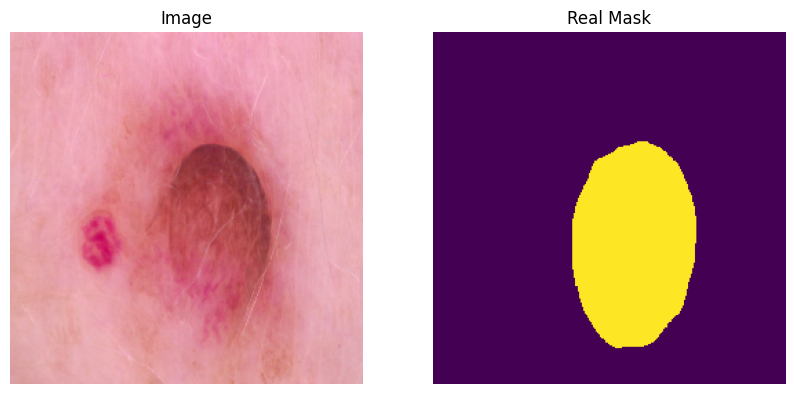

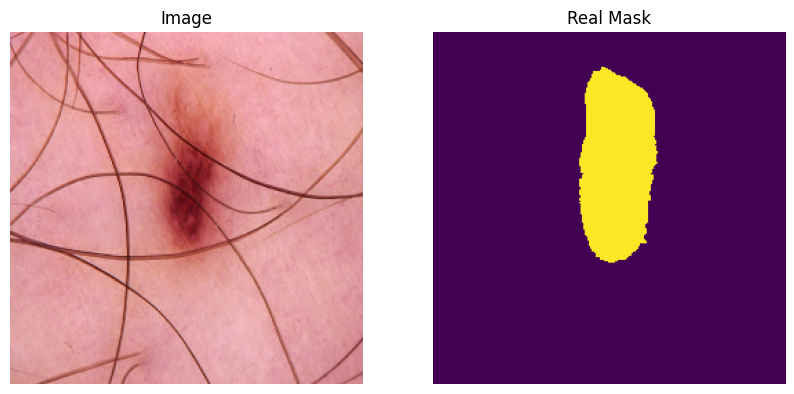

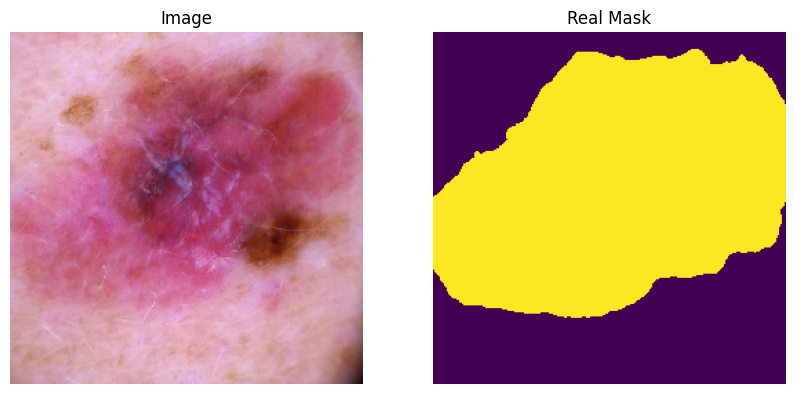

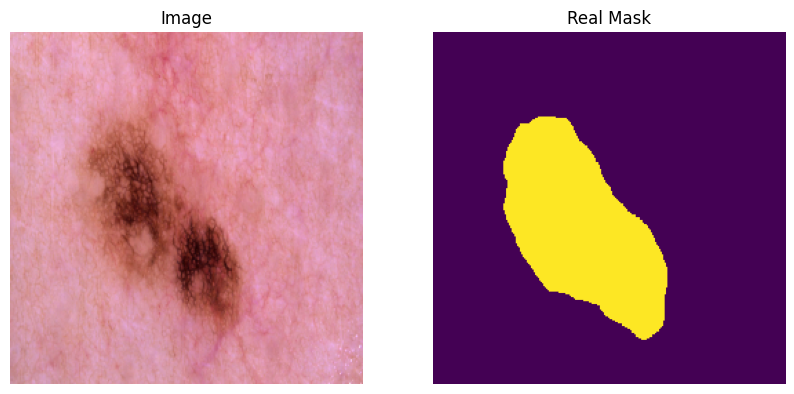

In [ ]:
for images, masks in test_batches.take(4):
  sample_image, sample_mask = images[0], masks[0]
  display([sample_image, sample_mask])

Ahora, vamos a crear el modelo UNET

In [ ]:
def unet_model(output_channels:int):
  input= tf.keras.layers.Input(shape=[IMAGE_SIZE,IMAGE_SIZE,3])

  #Codification
  #layer cod1
  conv1 = tf.keras.layers.Conv2D(8, (3,3), padding='same', activation='relu')(input)
  conv1 = tf.keras.layers.Conv2D(8, (3,3), padding='same', activation='relu')(conv1)
  pool1 = tf.keras.layers.MaxPooling2D((2,2))(conv1)

  #layer cod2
  conv2 = tf.keras.layers.Conv2D(16, (3,3), padding='same', activation='relu')(pool1)
  conv2 = tf.keras.layers.Conv2D(16, (3,3), padding='same', activation='relu')(conv2)
  pool2 = tf.keras.layers.MaxPooling2D((2,2))(conv2)

  #layer cod3

  conv3 = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu')(pool2)
  conv3 = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu')(conv3)
  pool3 = tf.keras.layers.MaxPooling2D((2,2))(conv3)

  #layer cod4

  conv4 = tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu')(pool3)
  conv4 = tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu')(conv4)
  pool4 = tf.keras.layers.MaxPooling2D((2,2))(conv4)

  #layer cod5

  conv5 = tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu')(pool4)
  conv5 = tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu')(conv5)

  #Decoding

  decod1 = tf.keras.layers.Conv2DTranspose(64, (2,2), strides=2, padding='same')(conv5)
  decod1 = tf.keras.layers.Concatenate()([decod1,conv4])
  decod1 = tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu')(decod1)
  decod1 = tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu')(decod1)

  decod2 = tf.keras.layers.Conv2DTranspose(32, (2,2), strides=2, padding='same')(decod1)
  decod2 = tf.keras.layers.Concatenate()([decod2, conv3])
  decod2 = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu')(decod2)
  decod2 = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu')(decod2)

  decod3 = tf.keras.layers.Conv2DTranspose(16, (2,2), strides=2, padding='same')(decod2)
  decod3 = tf.keras.layers.Concatenate()([decod3,conv2])
  decod3 = tf.keras.layers.Conv2D(16, (3,3), padding='same', activation='relu')(decod3)
  decod3 = tf.keras.layers.Conv2D(16, (3,3), padding='same', activation='relu')(decod3)

  decod4 = tf.keras.layers.Conv2DTranspose(8, (2,2), strides=2, padding='same')(decod3)
  decod4 = tf.keras.layers.Concatenate()([decod4,conv1])
  decod4 = tf.keras.layers.Conv2D(8, (3,3), padding='same', activation='relu')(decod4)
  decod4 = tf.keras.layers.Conv2D(8, (3,3), padding='same', activation='relu')(decod4)

  output = tf.keras.layers.Conv2D(output_channels, (1,1), activation='softmax')(decod4)

  return tf.keras.Model(inputs=input, outputs=output)

In [ ]:
OUTPUT_CLASSES = 2

model = unet_model(output_channels=OUTPUT_CLASSES)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │        224 │ input_layer_1[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │        584 │ conv2d_19[0][0]   │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │      1,168 │ max_pooling2d_4[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │      2,320 │ conv2d_21[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_5[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_23[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_25[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 16, 16,    │    147,584 │ conv2d_27[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 32, 32,    │     32,832 │ conv2d_28[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 485,826 (1.85 MB)

 Trainable params: 485,826 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

In [ ]:
def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = unet_model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(unet_model.predict(sample_image[tf.newaxis, ...]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step


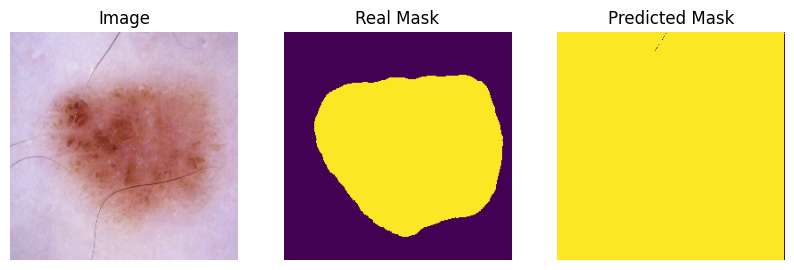

In [ ]:
show_predictions()

In [ ]:
class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


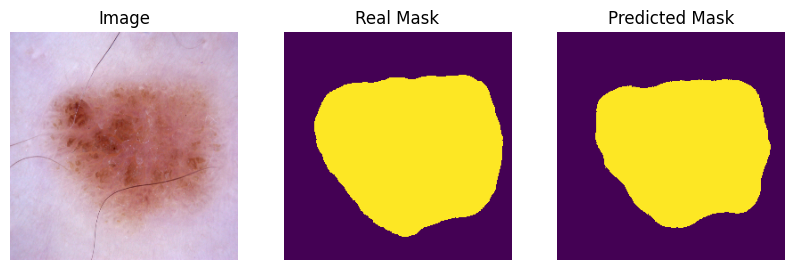


Sample Prediction after epoch 20

125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 547ms/step - accuracy: 0.9596 - loss: 0.1030 - val_accuracy: 0.9568 - val_loss: 0.1124


In [ ]:
EPOCHS = 20
model_history = model.fit(train_batches, epochs=EPOCHS,
                          validation_data=validation_batches,
                          callbacks=[DisplayCallback()])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


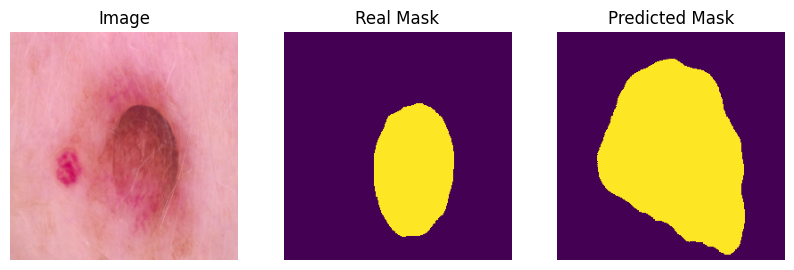

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


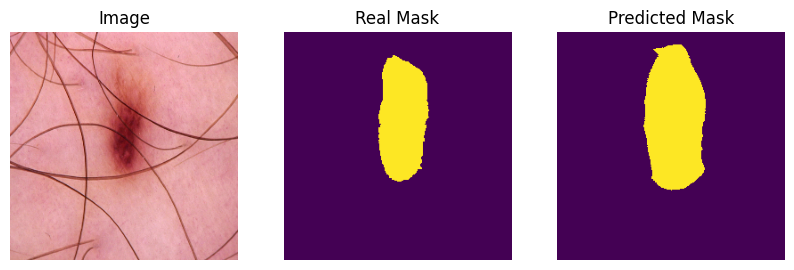

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


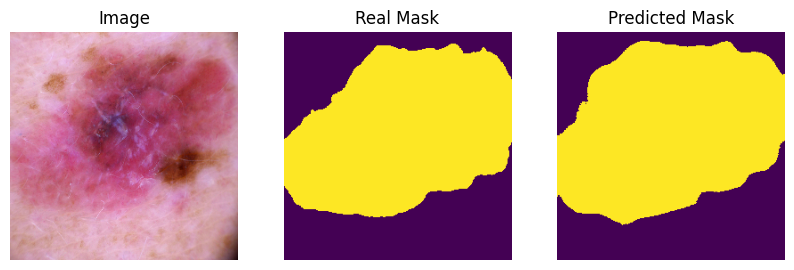

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


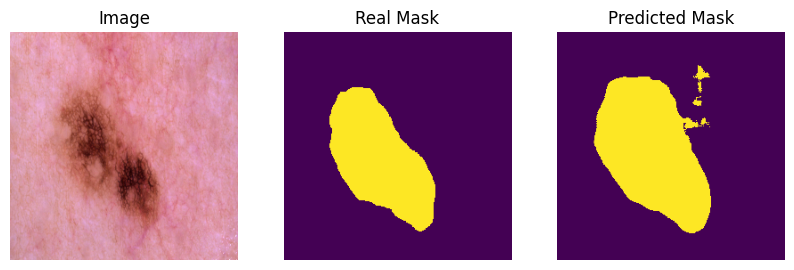

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


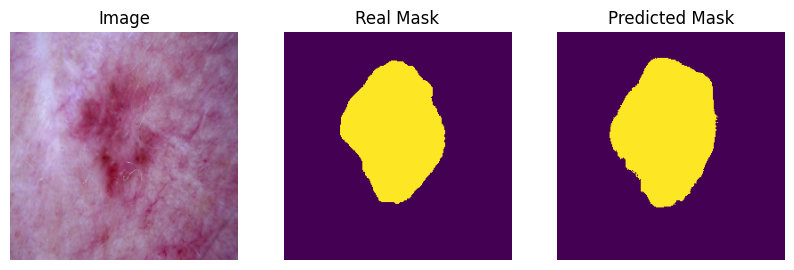

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


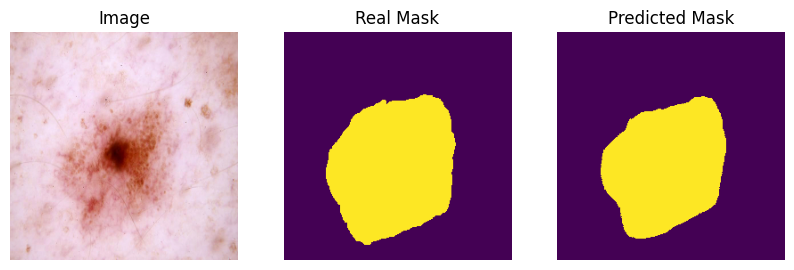

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


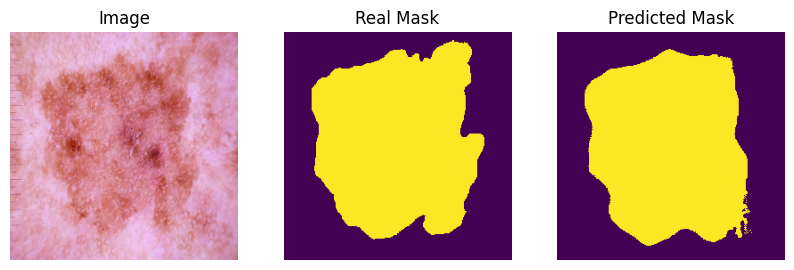

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


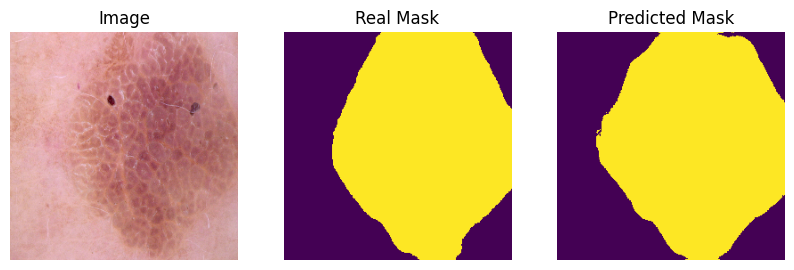

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


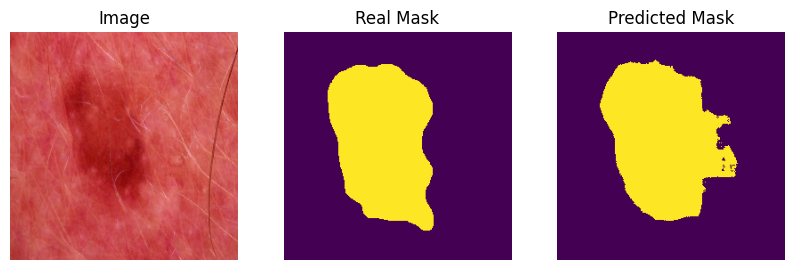

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


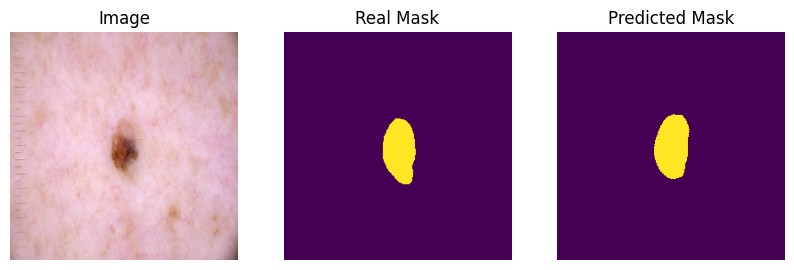

In [ ]:
show_predictions(test_batches,num=10)

Probaremos ahora con una imagen obtenida desde un movil

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


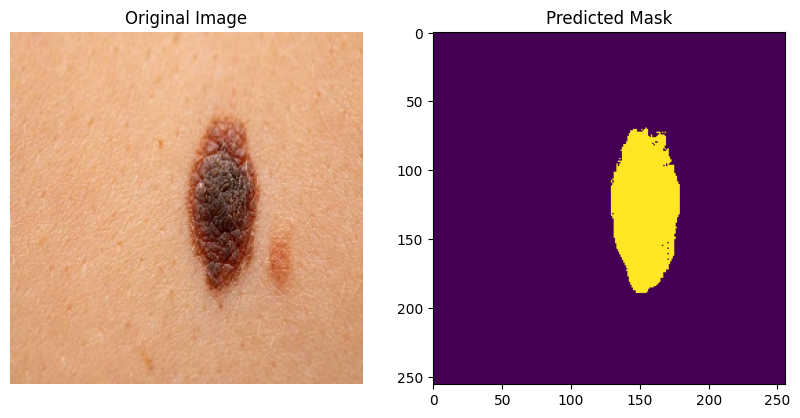

In [ ]:
image = tf.io.read_file('melanoma.jpg')
image = tf.image.decode_jpeg(image, channels=3)
image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(tf.keras.utils.array_to_img(image))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Predicted Mask')
plt.imshow(tf.keras.utils.array_to_img(create_mask(model.predict(image[tf.newaxis, ...]))))

plt.show()

In [ ]:
tf.keras.backend.clear_session()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


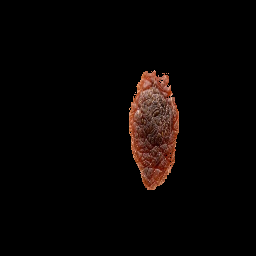

In [ ]:
def crop_image(image, mask):
  mask = np.array(mask)

  mask = mask.astype(np.float32)

  cropped_image = image * mask

  cropped_image = tf.keras.utils.array_to_img(cropped_image)

  return cropped_image

crop_image(image,create_mask(model.predict(image[tf.newaxis, ...])))

In [ ]:
model.save('unet.keras')

Una vez tenemos creado el modelo de segmentacion, pasamos a crear el modelo de clasificacion

Para crear el clasificador, necesitamos dos cosas, recortar todas las imagenes con sus respectivas máscaras y asignarles la predicción de

Primero, vamos a crear una función para recortar todos los datos de entrenamiento

In [ ]:
def crop_and_save_dataset(images_paths, masks_paths,labels):
  if not os.path.exists('cropped_images'):
    os.mkdir('cropped_images')
  if not os.path.exists('cropped_images/benign'):
    os.mkdir('cropped_images/benign')
  if not os.path.exists('cropped_images/malignant'):
    os.mkdir('cropped_images/malignant')
  for image_path in images_paths:
    image_id = image_path.split('/')[-1].split('.')[0]
    image, mask=load_image(image_path, masks_paths[images_paths.index(image_path)])
    if image_id in labels.index:
      benign_malignant=labels.loc[image_id]['benign_malignant']
      cropped_image=crop_image(image, mask)
      cropped_image.save('cropped_images/'+benign_malignant+'/'+image_id+'.jpg')
    else:
      print(image_id+' is not labeled')




df=pd.read_csv('ham10000.csv')
df_drop_na=df[['isic_id','benign_malignant']].dropna()
df_final = df_drop_na.set_index('isic_id')
crop_and_save_dataset(X_train,y_train,df_final)


KeyError: "['benign_malignant'] not in index"

In [ ]:
crop_and_save_dataset(X_validation,y_validation,df_final)

ISIC_0025661 is not labeled
ISIC_0024386 is not labeled
ISIC_0030959 is not labeled
ISIC_0027371 is not labeled
ISIC_0031378 is not labeled
ISIC_0027004 is not labeled
ISIC_0030705 is not labeled
ISIC_0034283 is not labeled
ISIC_0028079 is not labeled
ISIC_0032303 is not labeled
ISIC_0027825 is not labeled
ISIC_0025819 is not labeled
ISIC_0024345 is not labeled
ISIC_0028165 is not labeled
ISIC_0031078 is not labeled
ISIC_0026643 is not labeled
ISIC_0030723 is not labeled
ISIC_0027801 is not labeled
ISIC_0028570 is not labeled
ISIC_0029176 is not labeled
ISIC_0032826 is not labeled
ISIC_0026607 is not labeled
ISIC_0032159 is not labeled
ISIC_0028224 is not labeled
ISIC_0033908 is not labeled
ISIC_0031130 is not labeled
ISIC_0029912 is not labeled
ISIC_0025530 is not labeled
ISIC_0028490 is not labeled
ISIC_0029776 is not labeled
ISIC_0031012 is not labeled
ISIC_0032076 is not labeled
ISIC_0032660 is not labeled
ISIC_0024402 is not labeled
ISIC_0030230 is not labeled
ISIC_0032834 is not 

Una vez tenemos guardadas todas las imágenes recortadas, creamos un dataset.

In [ ]:
cropped_images_dir='./cropped_images'


In [ ]:
train_ds= tf.keras.utils.image_dataset_from_directory(
    cropped_images_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)


Found 7818 files belonging to 2 classes.
Using 6255 files for training.


In [ ]:
val_ds= tf.keras.utils.image_dataset_from_directory(
    cropped_images_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 7818 files belonging to 2 classes.
Using 1563 files for validation.


A continuación, creamos el modelo. Vamos a usar MobileNet, ya que es especialmente recomendado para aplicaciones moviles

In [ ]:
def classifier(classes:int):
  base_model = tf.keras.applications.MobileNetV3Large(
      input_shape=(IMAGE_SIZE,IMAGE_SIZE , 3),
      include_top=False,
      weights='imagenet'
  )

  base_model.trainable = False

  attended_features = spatial_attention_block(base_model.output)

  model = tf.keras.Sequential([
      tf.keras.Model(inputs=base_model.input,outputs=attended_features),
      tf.keras.layers.GlobalAveragePooling2D(),
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.Dropout(0.2),
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dropout(0.1),
      tf.keras.layers.Dense(classes, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=['accuracy',tf.keras.metrics.Recall(class_id=1)])
  return model

classifier_model=classifier(2)
classifier_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ functional_18 (Functional)           │ (None, 8, 8, 960)           │       2,997,313 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_10          │ (None, 960)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 128)                 │         123,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,128,707 (11.94 MB)

 Trainable params: 132,355 (517.01 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Precisión (Accuracy): 0.84375


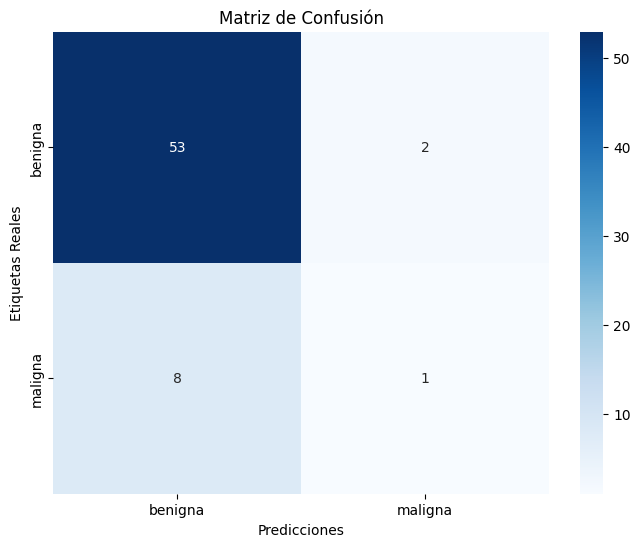

In [ ]:
test_batch = train_ds.take(1)
predictions=classifier_model.predict(test_batch)

for images, labels_real in test_batch:
    labels_real = labels_real.numpy()

predicted_classes = np.argmax(predictions, axis=1)

accuracy = accuracy_score(labels_real, predicted_classes)
print(f"Precisión (Accuracy): {accuracy}")


conf_matrix = confusion_matrix(labels_real, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["benigna", "maligna"],
            yticklabels=["benigna", "maligna"])
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas Reales')
plt.title('Matriz de Confusión')
plt.show()


Vamos ahora a entrenar nuestro modelo para que extraiga las características necesarias

In [ ]:
history=classifier_model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 32s 197ms/step - accuracy: 0.8220 - loss: 0.4137 - recall_7: 0.2157 - val_accuracy: 0.8842 - val_loss: 0.2611 - val_recall_7: 0.1094
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8889 - loss: 0.2659 - recall_7: 0.0779 - val_accuracy: 0.8957 - val_loss: 0.2478 - val_recall_7: 0.0625
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8962 - loss: 0.2454 - recall_7: 0.0612 - val_accuracy: 0.9008 - val_loss: 0.2405 - val_recall_7: 0.1172
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9035 - loss: 0.2286 - recall_7: 0.0705 - val_accuracy: 0.8976 - val_loss: 0.2407 - val_recall_7: 0.0781
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9083 - loss: 0.2269 - recall_7: 0.1080 - val_accuracy: 0.9008 - val_loss: 0.2416 - val_recall_7: 0.0312
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9124 - loss: 0.2111 - recall_7: 0.0885 - val_accuracy: 0.9021 - val_loss: 0.2408 - val_r

In [ ]:
tf.keras.backend.clear_session()

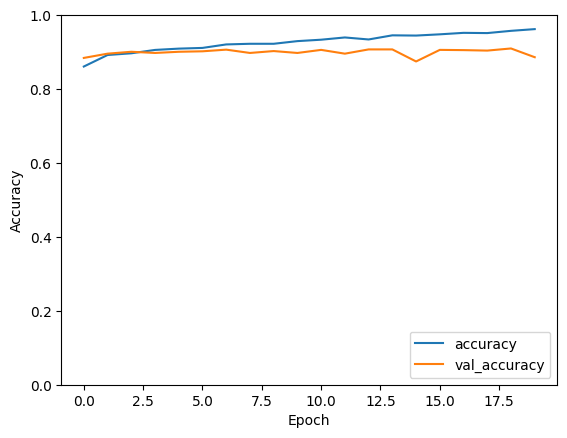

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Precisión (Accuracy): 0.8867562380038387


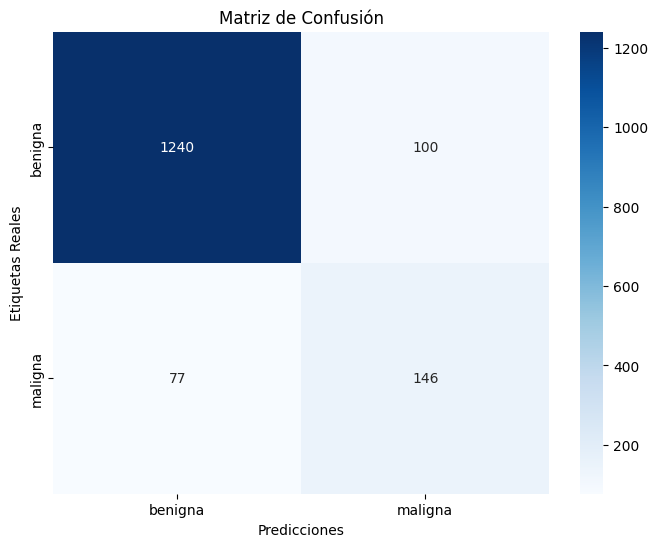

In [ ]:
test_batch = val_ds
predictions = []  # Store predictions from each batch
all_labels_real = []  # Store labels from each batch

for images, labels_real in test_batch:
    batch_predictions = classifier_model.predict(images)
    predictions.extend(np.argmax(batch_predictions, axis=1))
    all_labels_real.extend(labels_real.numpy())

accuracy = accuracy_score(all_labels_real, predictions)
print(f"Precisión (Accuracy): {accuracy}")


conf_matrix = confusion_matrix(all_labels_real, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["benigna", "maligna"],
            yticklabels=["benigna", "maligna"])
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas Reales')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
classifier_model.save('classifier.keras')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def mostrar_predicciones_con_etiquetas(dataset, num_imagenes=5):
    """
    Muestra las imágenes con sus etiquetas reales y las puntuaciones de predicción.
    """

    for images, labels_real in dataset.take(num_imagenes):
        batch_predictions = classifier_model.predict(images)
        predicted_classes = np.argmax(batch_predictions, axis=1)
        prediction_scores = np.max(batch_predictions, axis=1)

        for i in range(images.shape[0]):
            plt.figure(figsize=(8, 4))
            plt.subplot(1, 2, 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"Imagen {i + 1}")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.bar(["Benigno", "Maligno"], batch_predictions[i])
            plt.title(f"Etiqueta real: {'Benigno' if labels_real[i] == 0 else 'Maligno'}\nPredicción: {'Benigno' if predicted_classes[i] == 0 else 'Maligno'} ({prediction_scores[i]:.2f})")
            plt.ylim([0, 1])
            plt.show()

mostrar_predicciones_con_etiquetas(val_ds, num_imagenes=1)


Output hidden; open in https://colab.research.google.com to view.